# **Inteligência Artificial Aplicada - 2026/1**

# **Trabalho 3: Comparação de Modelos de Random Forest para Previsão de Temperatura Máxima com Análise de Importância de Variáveis**

**Professor:** Cícero Ferreira Fernandes Costa Filho  
**Aluno(a):** Maria Giovanna Gonçalves Sales - 22251138

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Carregamento de dados

In [ ]:
# vamos ler o arquivo excel e salvar como csv
df = pd.read_excel('temps_extended.xlsx')
df.to_csv('temps_extended.csv', index=False)

df

,year,month,day,weekday,ws_1,prcp_1,snwd_1,temp_2,temp_1,average,actual,friend
0,2011,1,1,Sat,4.92,0.00,0,36,37,45.6,40,40
1,2011,1,2,Sun,5.37,0.00,0,37,40,45.7,39,50
2,2011,1,3,Mon,6.26,0.00,0,40,39,45.8,42,42
3,2011,1,4,Tues,5.59,0.00,0,39,42,45.9,38,59
4,2011,1,5,Wed,3.80,0.03,0,42,38,46.0,45,39
...,...,...,...,...,...,...,...,...,...,...,...,...
2186,2016,12,28,Wed,15.21,0.05,0,42,44,45.3,47,30
2187,2016,12,29,Thurs,8.72,0.00,0,44,47,45.3,48,63
2188,2016,12,30,Fri,8.50,0.05,0,47,48,45.4,45,57
2189,2016,12,31,Sat,6.93,0.02,0,48,45,45.5,38,56


# Pré-processamento
Nessa parte, vamos remover os valores ausentes (NaN).

Além disso, aplicamos o `LabelEncoder` para o mapeamento apropriado das colunas categóricas. Como visto na base, a coluna `weekday` é tratada corretamente aqui.

In [ ]:
# drop de valores ausentes
df = df.dropna()

# usando LabelEncoder para o mapeamento adequado de variáveis categóricas
encoder = LabelEncoder()
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = encoder.fit_transform(df[col])

df

,year,month,day,weekday,ws_1,prcp_1,snwd_1,temp_2,temp_1,average,actual,friend
0,2011,1,1,2,4.92,0.00,0,36,37,45.6,40,40
1,2011,1,2,3,5.37,0.00,0,37,40,45.7,39,50
2,2011,1,3,1,6.26,0.00,0,40,39,45.8,42,42
3,2011,1,4,5,5.59,0.00,0,39,42,45.9,38,59
4,2011,1,5,6,3.80,0.03,0,42,38,46.0,45,39
...,...,...,...,...,...,...,...,...,...,...,...,...
2186,2016,12,28,6,15.21,0.05,0,42,44,45.3,47,30
2187,2016,12,29,4,8.72,0.00,0,44,47,45.3,48,63
2188,2016,12,30,0,8.50,0.05,0,47,48,45.4,45,57
2189,2016,12,31,2,6.93,0.02,0,48,45,45.5,38,56


# Seleção de variáveis e normalização
Conforme especificado no enunciado do trabalho, utilizaremos exatamente cinco variáveis para a predição: `year`, `ws_1`, `temp_2`, `temp_1`, `average`.

A variável alvo para a previsão da temperatura máxima é a `actual`.

In [ ]:
# definindo features (X) e target (y)
features = ['year', 'ws_1', 'temp_2', 'temp_1', 'average']
X = df[features]
y = df['actual']

# normalização dos dados de entrada
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df

,year,ws_1,temp_2,temp_1,average
0,-1.463718,-0.777280,-1.924213,-1.848536,-1.368659
1,-1.463718,-0.634615,-1.847776,-1.619166,-1.359340
2,-1.463718,-0.352456,-1.618466,-1.695622,-1.350020
3,-1.463718,-0.564868,-1.694903,-1.466252,-1.340701
4,-1.463718,-1.132356,-1.465592,-1.772079,-1.331381
...,...,...,...,...,...
2186,1.461848,2.484985,-1.465592,-1.313339,-1.396618
2187,1.461848,0.427444,-1.312718,-1.083968,-1.396618
2188,1.461848,0.357697,-1.083408,-1.007512,-1.387299
2189,1.461848,-0.140044,-1.006971,-1.236882,-1.377979


# Divisão dos conjuntos de Treino e Teste
Vamos separar a base em 75% para treinamento e 25% para teste, conforme as instruções do trabalho.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.25, random_state=42)

print(f"Tamanho do conjunto de treino: {X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")

Tamanho do conjunto de treino: (1643, 5)
Tamanho do conjunto de teste: (548, 5)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Modelo 1

In [ ]:
modelo_1 = RandomForestRegressor(n_estimators=600, max_depth=10, min_samples_leaf=1, min_samples_split=10, bootstrap=True, random_state=42)

modelo_1.fit(X_train, y_train)

y_pred_1 = modelo_1.predict(X_test)

metrics_1 = {
    'MSE': mean_squared_error(y_test, y_pred_1),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_1)),
    'MAE': mean_absolute_error(y_test, y_pred_1),
    'R2': r2_score(y_test, y_pred_1)
}

for k, v in metrics_1.items(): print(f"{k}: {v:.4f}")

MSE: 22.7256
RMSE: 4.7671
MAE: 3.7457
R2: 0.8600


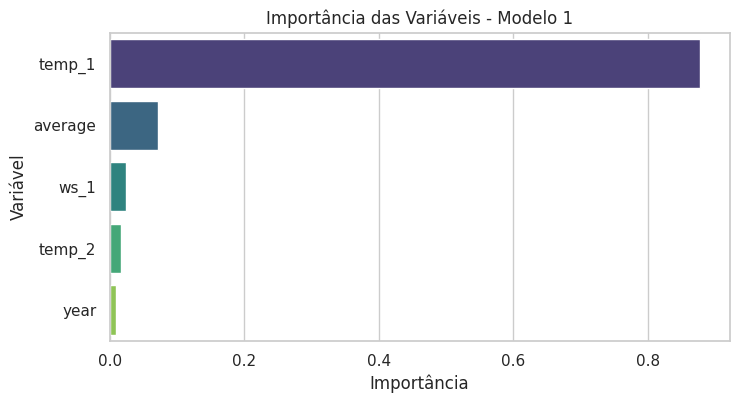

In [ ]:
importances_1 = modelo_1.feature_importances_
df_imp_1 = pd.DataFrame({'Variável': features, 'Importância': importances_1}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importância', y='Variável', data=df_imp_1, palette='viridis', hue='Variável', legend=False)
plt.title('Importância das Variáveis - Modelo 1')
plt.show()

# Modelo 2

In [ ]:
modelo_2 = RandomForestRegressor(n_estimators=200, max_depth=3, min_samples_leaf=4, min_samples_split=5, bootstrap=True, random_state=42)

modelo_2.fit(X_train, y_train)

y_pred_2 = modelo_2.predict(X_test)

metrics_2 = {
    'MSE': mean_squared_error(y_test, y_pred_2),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_2)),
    'MAE': mean_absolute_error(y_test, y_pred_2),
    'R2': r2_score(y_test, y_pred_2)
}

for k, v in metrics_2.items(): print(f"{k}: {v:.4f}")

MSE: 23.3721
RMSE: 4.8345
MAE: 3.7324
R2: 0.8560


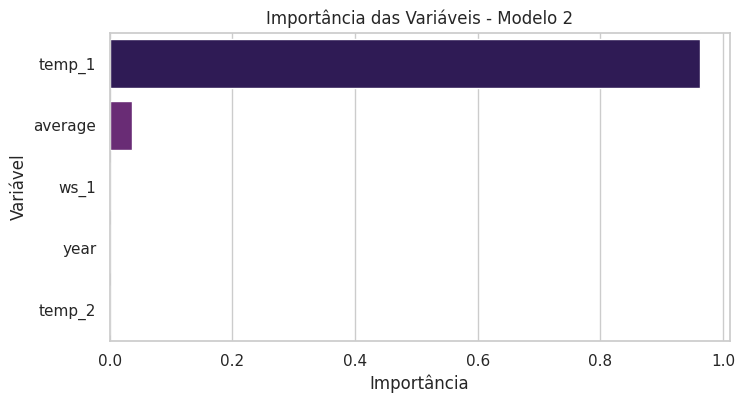

In [ ]:
importances_2 = modelo_2.feature_importances_
df_imp_2 = pd.DataFrame({'Variável': features, 'Importância': importances_2}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importância', y='Variável', data=df_imp_2, palette='magma', hue='Variável', legend=False)
plt.title('Importância das Variáveis - Modelo 2')
plt.show()

# Modelo 3

In [ ]:
modelo_3 = RandomForestRegressor(n_estimators=400, max_depth=50, min_samples_leaf=2, min_samples_split=2, bootstrap=False, random_state=42)

modelo_3.fit(X_train, y_train)

y_pred_3 = modelo_3.predict(X_test)

metrics_3 = {
    'MSE': mean_squared_error(y_test, y_pred_3),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_3)),
    'MAE': mean_absolute_error(y_test, y_pred_3),
    'R2': r2_score(y_test, y_pred_3)
}

for k, v in metrics_3.items(): print(f"{k}: {v:.4f}")

MSE: 42.8899
RMSE: 6.5490
MAE: 5.1153
R2: 0.7358


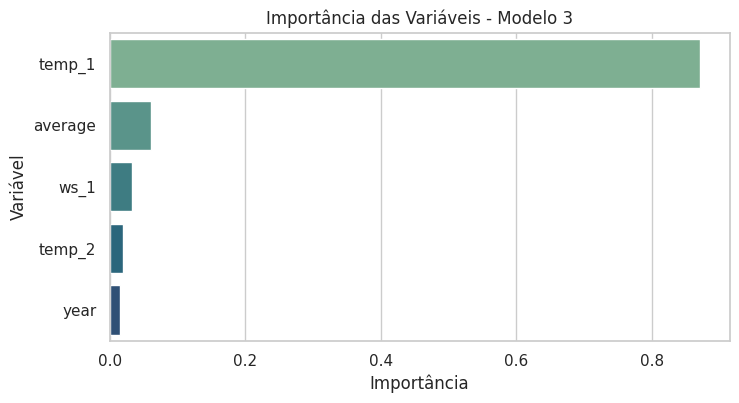

In [ ]:
importances_3 = modelo_3.feature_importances_
df_imp_3 = pd.DataFrame({'Variável': features, 'Importância': importances_3}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importância', y='Variável', data=df_imp_3, palette='crest', hue='Variável', legend=False)
plt.title('Importância das Variáveis - Modelo 3')
plt.show()

# Comparação entre todos os modelos

In [ ]:
df_metrics = pd.DataFrame([metrics_1, metrics_2, metrics_3], index=['Modelo 1', 'Modelo 2', 'Modelo 3'])

print("\nComparação de erros dos modelos")
display(df_metrics)

df_imp_all = pd.DataFrame({
    'Variável': features,
    'Modelo 1': importances_1,
    'Modelo 2': importances_2,
    'Modelo 3': importances_3
}).set_index('Variável')

print("\n\nComparação da importância das variáveis")
display(df_imp_all)



Comparação de erros dos modelos


,MSE,RMSE,MAE,R2
Modelo 1,22.725559,4.767133,3.745661,0.859985
Modelo 2,23.372147,4.834475,3.732400,0.856002
Modelo 3,42.889905,6.549038,5.115279,0.735751




Comparação da importância das variáveis


,Modelo 1,Modelo 2,Modelo 3
Variável,,,
year,0.009684,0.000000,0.015863
ws_1,0.024963,0.000371,0.033150
temp_2,0.016219,0.000000,0.019567
temp_1,0.877658,0.962516,0.870752
average,0.071475,0.037113,0.060669


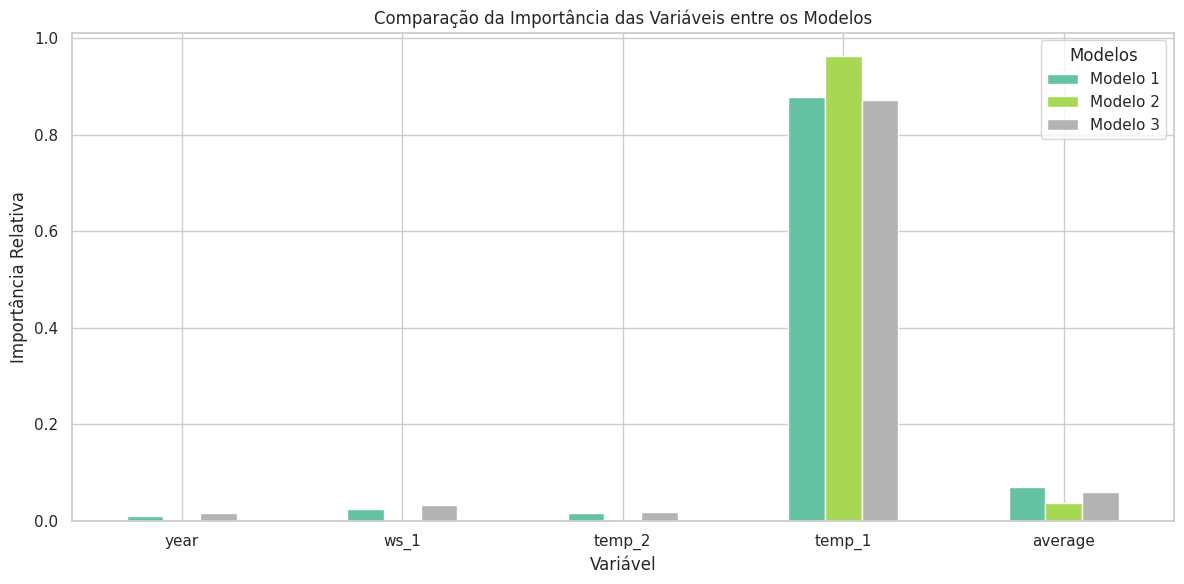

In [ ]:
df_imp_all.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Comparação da Importância das Variáveis entre os Modelos')
plt.ylabel('Importância Relativa')
plt.xticks(rotation=0)
plt.legend(title='Modelos')
plt.tight_layout()
plt.show()